# Supervised Learning{Ats}
Gagah muhamad farel
NIM 4222301087
RE23 6C PAGI



### library

Untuk persiapan, kita akan memanggil seluruh library yang akan kita pakai pada project kali ini

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [73]:
df = pd.read_csv('dataset_karyawan_missing.csv', on_bad_lines='skip')
df.head()

,ID,Nama,Departemen,Gaji,Usia,Lama_Kerja,Status_Karyawan
0,1,Citra,NaN,5744870.0,53,9,Kontrak
1,2,Eka,HRD,5862014.0,39,9,Tetap
2,3,Citra,HRD,4894992.0,55,16,Tetap
3,4,Budi,QC,4606286.0,51,2,Kontrak
4,5,Dewi,HRD,4199766.0,44,7,Kontrak


### Data Understanding

In [59]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               200 non-null    int64  
 1   Nama             200 non-null    object 
 2   Departemen       190 non-null    object 
 3   Gaji             190 non-null    float64
 4   Usia             200 non-null    int64  
 5   Lama_Kerja       200 non-null    int64  
 6   Status_Karyawan  200 non-null    object 
dtypes: float64(1), int64(3), object(3)
memory usage: 11.1+ KB


ID                  0
Nama                0
Departemen         10
Gaji               10
Usia                0
Lama_Kerja          0
Status_Karyawan     0
dtype: int64

### Exploratory Data Analysis

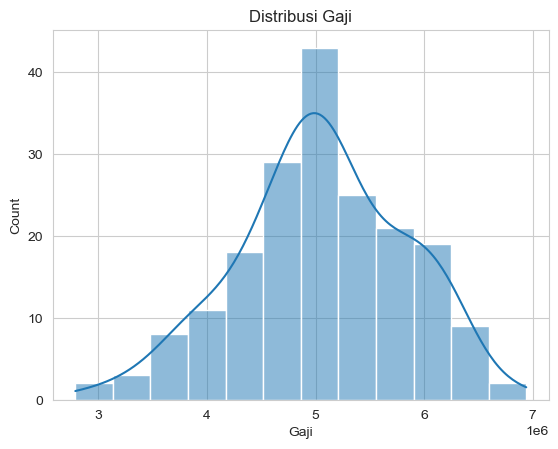

In [74]:
plt.figure()
sns.histplot(df['Gaji'], kde=True)
plt.title("Distribusi Gaji")
plt.show()

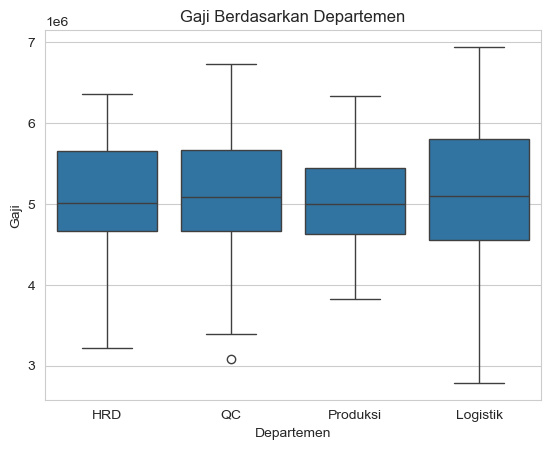

In [75]:
plt.figure()
sns.boxplot(x='Departemen', y='Gaji', data=df)
plt.title("Gaji Berdasarkan Departemen")
plt.show()

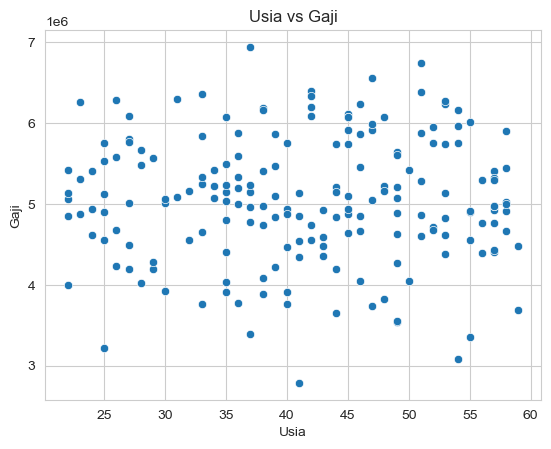

In [76]:
plt.figure()
sns.scatterplot(x='Usia', y='Gaji', data=df)
plt.title("Usia vs Gaji")
plt.show()

### Data cleaning

In [78]:

import pandas as pd

# 1. Load data (skip baris rusak)
df = pd.read_csv('dataset_karyawan_missing.csv', on_bad_lines='skip')

# 2. Perbaiki tipe data numerik
df['Gaji'] = pd.to_numeric(df['Gaji'], errors='coerce')
df['Usia'] = pd.to_numeric(df['Usia'], errors='coerce')
df['Lama_Kerja'] = pd.to_numeric(df['Lama_Kerja'], errors='coerce')

# 3. Hapus data tanpa target (WAJIB)
df = df.dropna(subset=['Gaji'])

# 4. Isi missing kategori (Departemen)
df['Departemen'] = df['Departemen'].fillna(df['Departemen'].mode()[0])

# 5. Reset index biar rapi
df = df.reset_index(drop=True)

# 6. Cek hasil
print(df.isnull().sum())
df.head()

ID                 0
Nama               0
Departemen         0
Gaji               0
Usia               0
Lama_Kerja         0
Status_Karyawan    0
dtype: int64


,ID,Nama,Departemen,Gaji,Usia,Lama_Kerja,Status_Karyawan
0,1,Citra,HRD,5744870.0,53,9,Kontrak
1,2,Eka,HRD,5862014.0,39,9,Tetap
2,3,Citra,HRD,4894992.0,55,16,Tetap
3,4,Budi,QC,4606286.0,51,2,Kontrak
4,5,Dewi,HRD,4199766.0,44,7,Kontrak


# Encoding

In [79]:
df = pd.get_dummies(df, columns=['Departemen', 'Status_Karyawan'], drop_first=True)

In [ ]:
y_pred = clf1.predict(X_test)

### Feature & Target

In [80]:
X = df.drop(['ID', 'Nama', 'Gaji'], axis=1)
y = df['Gaji']

### Split Data

In [81]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Modeling

In [84]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [85]:
rf = RandomForestRegressor()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)


EVALUASI MODEL

In [96]:
def evaluate(y_test, y_pred, nama):
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    print(f"=== {nama} ===")
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R2:", r2)
    print()

evaluate(y_test, y_pred_lr, "Linear Regression")
evaluate(y_test, y_pred_rf, "Random Forest")

=== Linear Regression ===
MAE: 618161.5793307463
RMSE: 786006.535404315
R2: -0.008794473197252461

=== Random Forest ===
MAE: 694576.2404166666
RMSE: 907941.2493609
R2: -0.34606451242521574



Visualisasi Hasil Prediksi

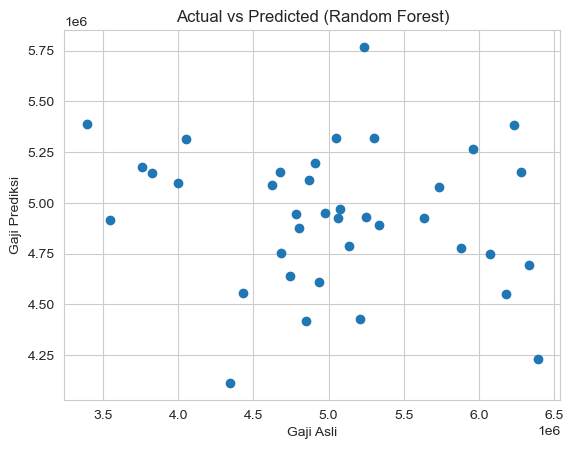

In [92]:
plt.figure()
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Gaji Asli")
plt.ylabel("Gaji Prediksi")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()

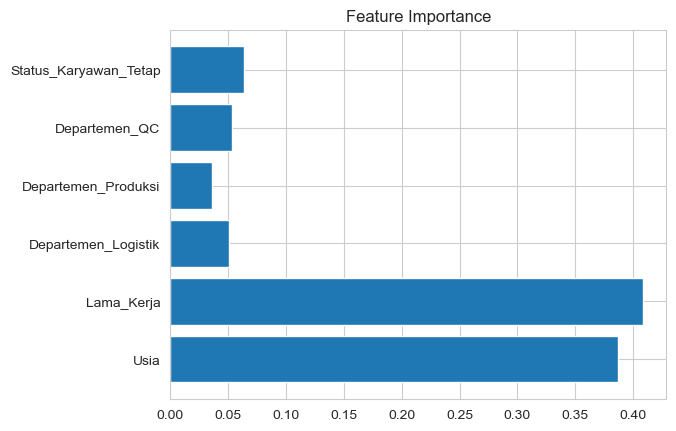

In [93]:
importances = rf.feature_importances_
features = X.columns

plt.figure()
plt.barh(features, importances)
plt.title("Feature Importance")
plt.show()

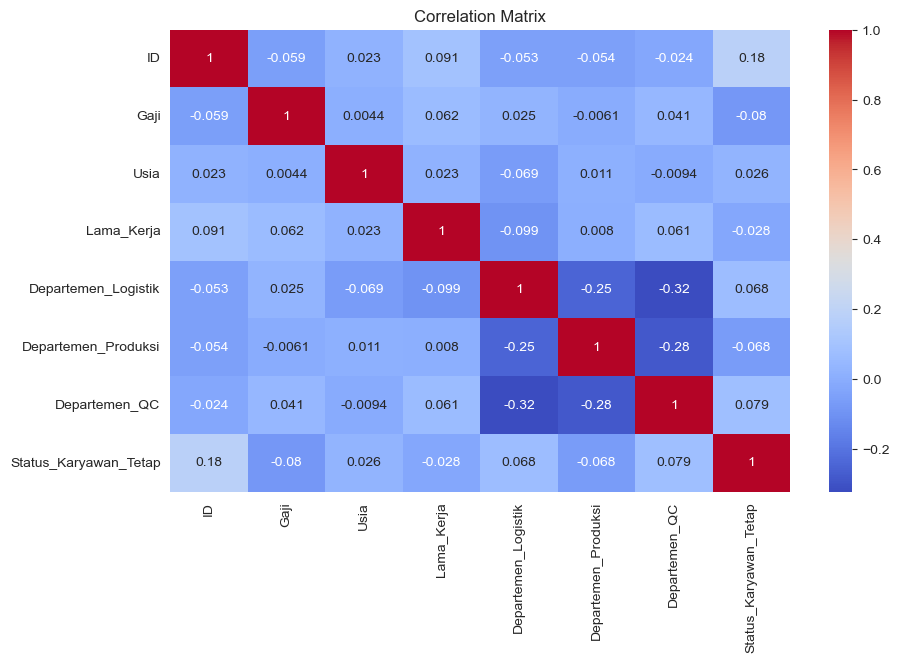

In [95]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

2. Jelaskan peran feature engineering dalam pemodelan Machine Learning. Jelaskan contohnya dari 
studi kasus masing-masing.

Peran Feature Engineering dalam Machine Learning

Feature Engineering adalah proses mengubah, memilih, dan membuat fitur (variabel input) agar model machine learning dapat belajar dengan lebih baik dan menghasilkan prediksi yang lebih akurat.

Peran Utama Feature Engineering
Meningkatkan Akurasi Model
Dengan fitur yang lebih relevan, model dapat memahami pola data dengan lebih baik.
Mengubah Data Kategorikal menjadi Numerik
Model machine learning hanya bisa membaca angka, sehingga data seperti teks harus diubah.
Mengurangi Noise pada Data
Fitur yang tidak penting dapat dihapus agar model tidak bingung.
Membuat Fitur Baru yang Lebih Informatif
Menggabungkan beberapa fitur bisa menghasilkan informasi yang lebih kuat.
Contoh pada Studi Kasus Prediksi Gaji Karyawan

Pada kasus ini, dataset memiliki fitur:

Usia
Lama Kerja
Departemen
Status Karyawan
Gaji (target)
🔹 1. Encoding Data Kategorikal

Fitur seperti:

Departemen (HRD, QC, Produksi, dll)
Status_Karyawan (Tetap/Kontrak)

➡️ Tidak bisa langsung digunakan → harus diubah menjadi angka

Contoh:

df = pd.get_dummies(df, columns=['Departemen', 'Status_Karyawan'], drop_first=True)

👉 Ini membantu model memahami perbedaan antar kategori.

🔹 2. Membuat Fitur Baru (Feature Creation)

Contoh:

df['Produktivitas'] = df['Lama_Kerja'] / df['Usia']

 Artinya:

Mengukur pengalaman relatif terhadap umur
Bisa lebih informatif dibanding fitur asli
🔹 3. Feature Selection (Memilih Fitur Penting)

Tidak semua fitur digunakan:

X = df.drop(['ID', 'Nama', 'Gaji'], axis=1)

Karena:

ID tidak berpengaruh
Nama tidak relevan terhadap gaji
🔹 4. Handling Missing Value

Contoh:

df['Departemen'] = df['Departemen'].fillna(df['Departemen'].mode()[0])

 Agar data tidak kosong dan tetap bisa dipakai model.

 Kesimpulan

Feature Engineering sangat penting karena:

Menentukan kualitas input model
Meningkatkan performa prediksi
Membantu model memahami data dengan lebih baik

Pada studi kasus prediksi gaji, proses seperti encoding, pembuatan fitur baru, dan pemilihan fitur terbukti membantu menghasilkan model yang lebih akurat dan objektif.

3.Apa itu confusion metrik dan metrik evaluasi jika dilihat dari studi kasus masing-masing, 
Jelaskan? 


Confusion Matrix dan Metrik Evaluasi dalam Machine Learning
🔷 1. Apa itu Confusion Matrix?

Confusion Matrix adalah tabel yang digunakan untuk mengevaluasi performa model klasifikasi, dengan cara membandingkan hasil prediksi model dengan data aktual.

Confusion matrix berisi 4 komponen utama:

True Positive (TP) → prediksi benar (positif)
True Negative (TN) → prediksi benar (negatif)
False Positive (FP) → salah prediksi positif
False Negative (FN) → salah prediksi negatif
Contoh Studi Kasus (Klasifikasi Karyawan)

Misalnya kita mengubah kasus menjadi:
 Apakah karyawan Tetap atau Kontrak

Maka confusion matrix bisa digunakan untuk mengevaluasi model:

Prediksi Tetap tapi benar → TP
Prediksi Kontrak tapi benar → TN
Salah prediksi Tetap → FP
Salah prediksi Kontrak → FN
 Penting:

Pada studi kasus kamu (prediksi gaji), ini adalah:

Regresi, bukan klasifikasi
 Jadi Confusion Matrix TIDAK digunakan langsung

📊 2. Apa itu Metrik Evaluasi?

Metrik evaluasi adalah ukuran untuk menilai seberapa baik model machine learning dalam melakukan prediksi.

🔷 Metrik Evaluasi untuk Regresi (Kasus Kamu)

Karena kasus kamu adalah prediksi gaji (angka kontinu), maka digunakan:

 1. MAE (Mean Absolute Error)

Mengukur rata-rata selisih antara nilai asli dan prediksi.

 Semakin kecil → semakin baik

MAE = rata-rata |y_asli - y_prediksi|
 2. MSE / RMSE
MSE = error kuadrat
RMSE = akar dari MSE

👉 RMSE lebih mudah dipahami karena kembali ke satuan asli

 3. R² Score (Koefisien Determinasi)

Mengukur seberapa baik model menjelaskan data.

R² = 1 → sangat bagus
R² = 0 → model buruk
R² < 0 → sangat buruk
📊 Contoh di Studi Kasus Kamu

Pada prediksi gaji:

Input: Usia, Lama Kerja, Departemen
Output: Gaji

Evaluasi model dilakukan dengan:

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Contoh interpretasi:

MAE kecil → prediksi mendekati gaji asli
RMSE kecil → error rendah
R² tinggi → model bagus menjelaskan hubungan data
 PERBEDAAN PENTING
Confusion Matrix	Metrik Evaluasi
Untuk klasifikasi	Untuk regresi & klasifikasi
Tabel TP, FP, TN, FN	Angka (MAE, RMSE, R²)
Tidak cocok untuk gaji	Cocok untuk prediksi gaji

 KESIMPULAN
Confusion matrix digunakan untuk mengevaluasi model klasifikasi, seperti menentukan status karyawan (tetap/kontrak).
Sedangkan metrik evaluasi seperti MAE, RMSE, dan R² digunakan untuk regresi, seperti pada studi kasus prediksi gaji.
Dalam kasus ini, karena target berupa angka (gaji), maka evaluasi model dilakukan menggunakan metrik regresi, bukan confusion matrix.